In [1]:
# install libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns



from datetime import datetime
from pathlib import Path
from collections import defaultdict




In [2]:
# load AMI files

current_path = Path(os.getcwd())
ami_folder = current_path / '..'/ 'NREL'

ind_load_csv = ami_folder / 'consumption'/ 'ch1_4301002_individual.csv'
location_ref = ami_folder / 'location_reference.csv'
agg_load_csv = ami_folder / 'consumption'/ 'ch1_4301002_aggregated.csv'
print('done')

done


In [30]:
# read csv and plot graphs

df = pd.read_csv(ind_load_csv)
df.head()


# Convert 'ENDTIME_EST' to datetime
df['ENDTIME_EST'] = pd.to_datetime(df['ENDTIME_EST'])
# Filter for dates from Jan 1 to Dec 31, 2024
df_2024 = df[(df['ENDTIME_EST'] >= '2024-01-01') & (df['ENDTIME_EST'] < '2025-01-01')]
# Filter for summer dates April to October
df_2024_summer = df[(df['ENDTIME_EST'] >= '2024-04-01') & (df['ENDTIME_EST'] < '2024-09-30')]
# Filter for winter dates Jan to March, Nov to Dec
df_2024_winter = df[
    ((df['ENDTIME_EST'] >= '2024-01-01') & (df['ENDTIME_EST'] < '2024-04-1')) | 
    ((df['ENDTIME_EST'] >= '2024-11-01') & (df['ENDTIME_EST'] < '2025-01-01'))
]

print("Max INTERVAL_READ:", df_2024['INTERVAL_READ'].max())
# Max INTERVAL_READ: 48.96
print("Max INTERVAL_READ summer:", df_2024_summer['INTERVAL_READ'].max())

print("Number of unique SERVICEPOINTID:", df_2024['SERVICEPOINTID'].nunique())


print(df_2024['INTERVAL_READ'].describe())
print("\nTop 10 highest INTERVAL_READ values:")
print(df_2024.sort_values('INTERVAL_READ', ascending=False).head(10))



print('done')


Max INTERVAL_READ: 48.96
Max INTERVAL_READ summer: 48.96
Number of unique SERVICEPOINTID: 670
count    2.138023e+07
mean     3.236023e-01
std      1.164701e+00
min      0.000000e+00
25%      5.600000e-02
50%      1.310000e-01
75%      2.880000e-01
max      4.896000e+01
Name: INTERVAL_READ, dtype: float64

Top 10 highest INTERVAL_READ values:
          SERVICEPOINTID  CHANNELNUMBER         ENDTIME_EST  INTERVAL_READ
13119859      6000984488              1 2024-05-22 11:30:00          48.96
13119866      6000984488              1 2024-05-22 13:15:00          48.96
13119860      6000984488              1 2024-05-22 11:45:00          48.48
13119863      6000984488              1 2024-05-22 12:30:00          48.48
13119869      6000984488              1 2024-05-22 14:00:00          48.48
13119865      6000984488              1 2024-05-22 13:00:00          47.76
13119856      6000984488              1 2024-05-22 10:45:00          47.52
13119870      6000984488              1 2024-05-22 14:15

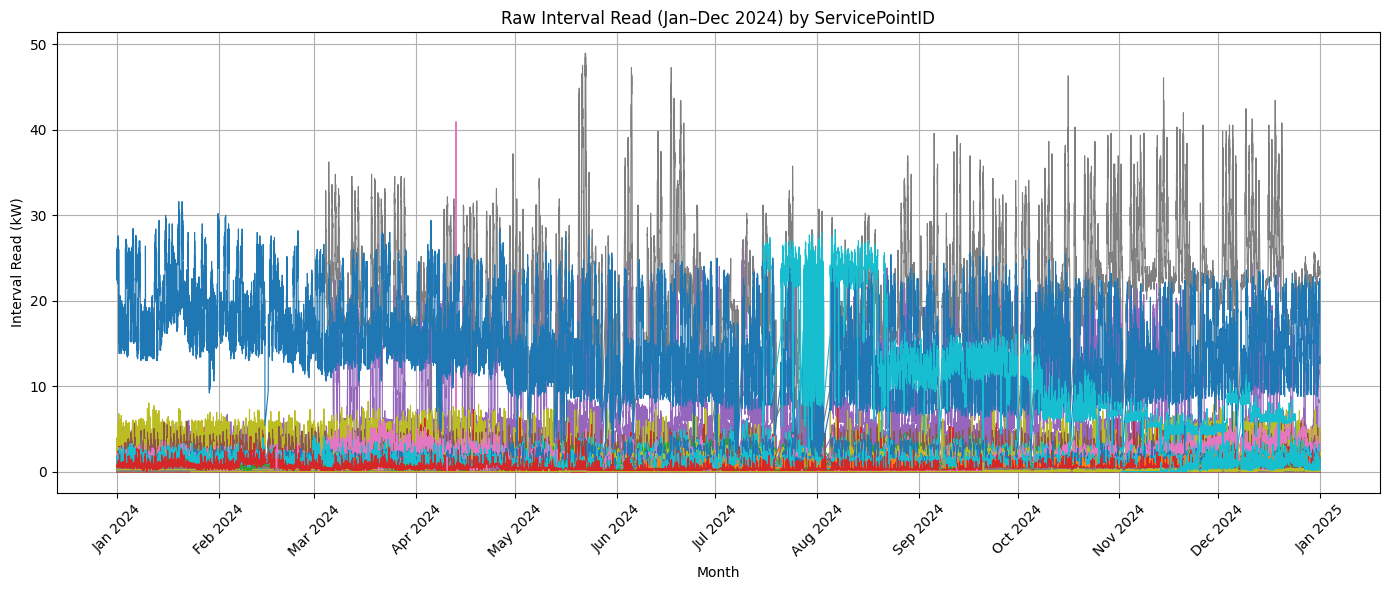

In [5]:
plt.figure(figsize=(14, 6))

for sp_id in df_2024['SERVICEPOINTID'].unique():
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
    plt.plot(sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'], label=f'SP {sp_id}', linewidth=0.8)

# Format x-axis to show month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels and layout
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title('Raw Interval Read (Jan–Dec 2024) by ServicePointID')
#plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small', ncol=1)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# read location reference


location_df = pd.read_csv(location_ref, dtype={'xfr_gisid': str, 'servicepointid': str})
location_df.head()

,servicepointid,circuit,xfr_gisid,amimeter,Residential,latitude,longitude
0,6000990168,4301002,220603575,Y,Res,42.491198,-76.299784
1,6000981995,4301002,220270492,Y,Res,42.494522,-76.304065
2,6000998944,4301002,220269834,Y,Res,42.491739,-76.273444
3,6000990452,4301002,220269968,Y,Res,42.497168,-76.279103
4,6000981895,4301002,220270495,Y,Res,42.494890,-76.305322


In [37]:
# Drop duplicate service points
unique_services = location_df.drop_duplicates(subset='servicepointid')

# Count residential and non-residential
num_residential = (unique_services['Residential'] == 'Res').sum()
num_non_residential = (unique_services['Residential'] == 'Non-Res').sum()

print(f"Unique Service Points: {len(unique_services)}")
print(f"Residential Customers: {num_residential}")
print(f"Non-Residential Customers: {num_non_residential}")


Unique Service Points: 676
Residential Customers: 566
Non-Residential Customers: 110


In [10]:
# service point id 

#node_id = ['220270493', '220270494', '220270496']

# Clean or standardize customer type column if needed
location_df['Residential'] = location_df['Residential'].str.strip()  # remove whitespace
location_df['Residential'] = location_df['Residential'].fillna('Unknown')  # handle NaNs

# Initialize nested defaultdict
nested_dict = defaultdict(lambda: defaultdict(list))

for _, row in location_df.iterrows():
    node_id = row['xfr_gisid']
    cust_type = row['Residential']
    servicepoint_id = row['servicepointid']
    nested_dict[node_id][cust_type].append(servicepoint_id)

# --- Step 3: Helper function to access servicepointids easily ---
def get_service_ids_by_type(load_id_dict, nested_dict, type_key='res'):
    """
    Given a load_id dictionary (e.g., {'res': '220603575'}),
    return list of servicepointids for that type (res or comm).
    """
    node_id = load_id_dict.get(type_key)
    if not node_id:
        return []
    # Capitalize 'res' → 'Res', 'comm' → 'Comm'
    cust_type = type_key.capitalize()
    return nested_dict.get(node_id, {}).get(cust_type, [])


print('done')

done


In [11]:
# LOAD ID 1


#load_id = {'res': '220269965'}
load_id = {'res': '220534982'}
service_ids = get_service_ids_by_type(load_id, nested_dict, 'res')
print(f"Residential servicepoint IDs for node {load_id['res']}: {service_ids}")

Residential servicepoint IDs for node 220534982: ['6003465929', '6003547689', '6003491218', '6003403818', '6003508063']


#### LOAD ID 1
#### FULL YEAR
#### INDIVIDUAL

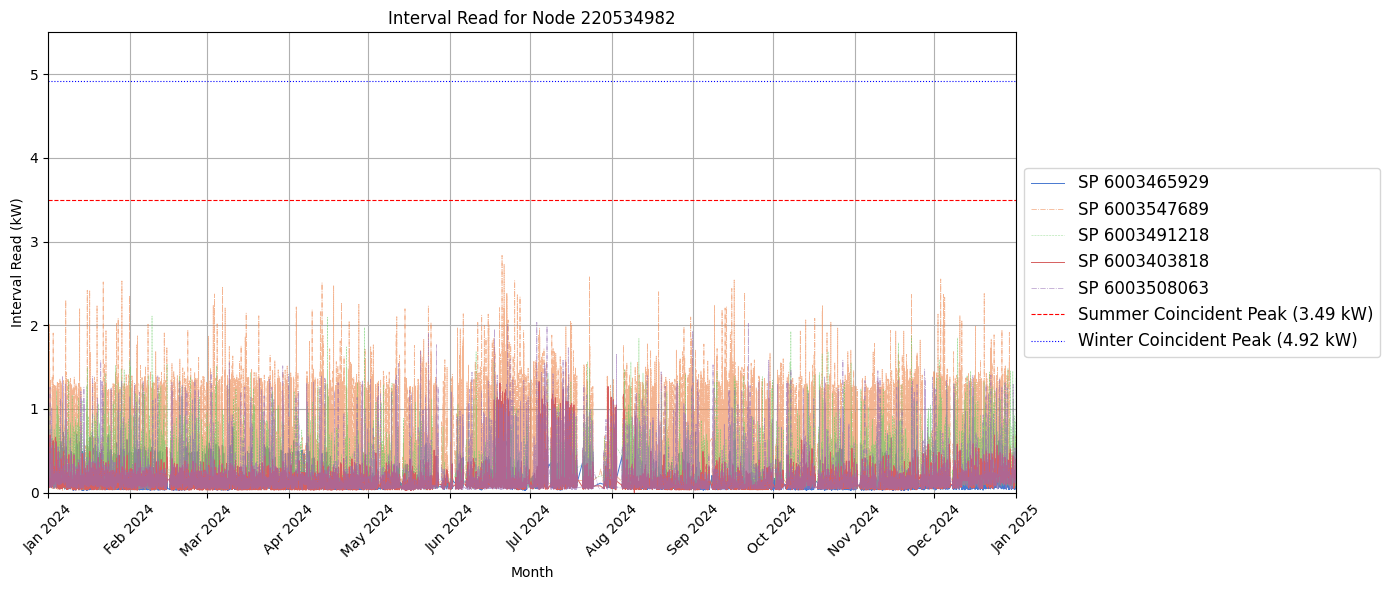

In [12]:
# LOAD ID 1
# FULL YEAR
# INDIVIDUAL

plt.figure(figsize=(14, 6))
df_2024 = df_2024.copy()
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)


# Define colors and styles for each line
#supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
linestyles = ['-', '-.', '--']
linewidths = [0.7, 0.6, 0.4]
#alpha=0.5 if i == 2 else 1.0
alphas = [1.0, 0.6, 0.6]
colors = sns.color_palette("muted", n_colors=len(service_ids))  # or "colorblind", "muted", "deep"

for i, sp_id in enumerate(service_ids):
    sp_data = df_2024[df_2024['SERVICEPOINTID'] == sp_id]
#    if not sp_data.empty:
#        plt.plot(sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'], label=f'SP {sp_id}', linewidth=0.8)

    if not sp_data.empty:
        plt.plot(sp_data['ENDTIME_EST'], 
                 sp_data['INTERVAL_READ'], 
                 color = colors[i],
                 linestyle = linestyles[i % 3],
                 linewidth = linewidths[i % 3],
                 alpha = alphas[i % 3],
                 label=f'SP {sp_id}')

# Format x-axis as months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))
plt.ylim(0, 5.5)

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
plt.axhline(y=4.915, color='blue', linestyle=':', linewidth=0.8, label='Winter Coincident Peak (4.92 kW)')


# Labels, legend, and formatting
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Interval Read for Node {load_id["res"]}')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='large')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Interval Read for Node.png', dpi=300, bbox_inches='tight')
plt.show()

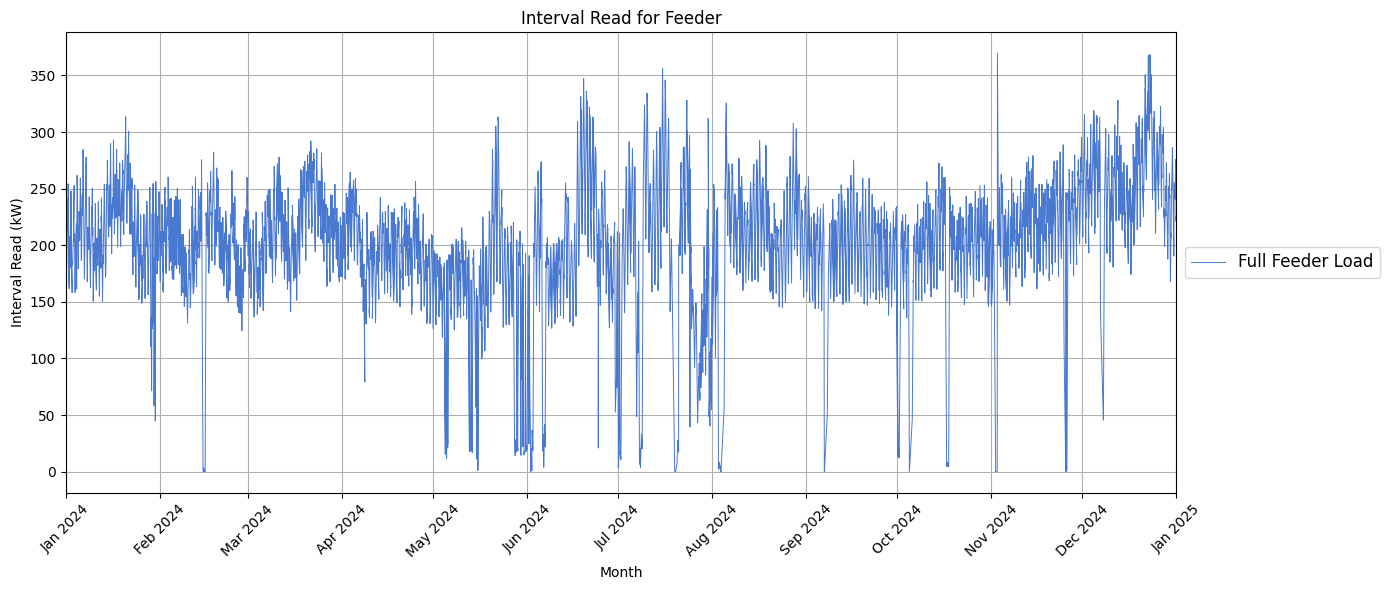

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import matplotlib as mpl
# Fix: Avoid OverflowError by simplifying paths and chunking
mpl.rcParams['path.simplify_threshold'] = 1.0
mpl.rcParams['agg.path.chunksize'] = 10000
df_2024 = df_2024.copy()
agg_df_feeder = df_2024.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

# Define plot
plt.figure(figsize=(14, 6))

# Style definitions
linestyle = '-'
linewidth = 0.7
alpha = 1.0
color = sns.color_palette("muted", n_colors=1)[0]  # single line

# Plot full feeder aggregated data
plt.plot(
    agg_df_feeder['ENDTIME_EST'],
    agg_df_feeder['INTERVAL_READ'],
    color=color,
    linestyle=linestyle,
    linewidth=linewidth,
    alpha=alpha,
    label='Full Feeder Load'
)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))
#plt.ylim(0, 5.5)

# Optional: Add peak lines
# plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
# plt.axhline(y=4.915, color='blue', linestyle=':', linewidth=0.8, label='Winter Coincident Peak (4.92 kW)')

# Labels, title, legend
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title('Interval Read for Feeder')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='large')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save and show
plt.savefig('Interval Read for full feeder.png', dpi=300, bbox_inches='tight')
plt.show()


#### LOAD ID 1
#### FULL YEAR
#### AGGREGATE

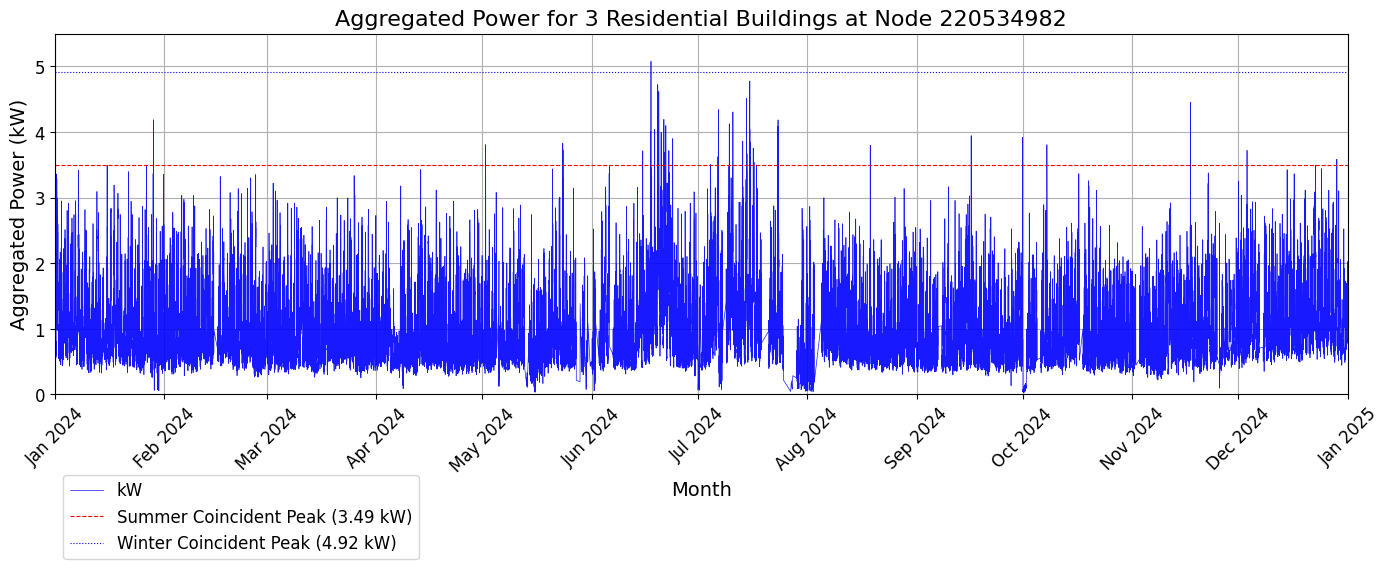

In [13]:
# LOAD ID 1
#FULL YEAR
# AGGREGATE
df_2024 = df_2024.copy()

# Make sure SERVICEPOINTID is string
df_2024['SERVICEPOINTID'] = df_2024['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024[df_2024['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kWh)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

# Plot kW
plt.figure(figsize=(14, 6))
plt.plot(agg_df['ENDTIME_EST'], agg_df['INTERVAL_READ'], label='kW', color='blue', linewidth=0.5, alpha = 0.9)

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
plt.axhline(y=4.915, color='blue', linestyle=':', linewidth=0.8, label='Winter Coincident Peak (4.92 kW)')


# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2025-01-01'))
plt.ylim(0, 5.5)

# Labels
plt.xlabel('Month', fontsize=14)
plt.ylabel('Aggregated Power (kW)', fontsize=14)
plt.title(f'Aggregated Power for 3 Residential Buildings at Node {load_id["res"]}', fontsize=16)
plt.grid(True)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, -0.20),  # Bottom left outside the plot
    fontsize='large',
    frameon=True,
    ncol=1
)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('Aggregate Power for Node.png', dpi=600, bbox_inches='tight')  # Increased to 600 dpi for even higher quality

plt.show()



Individual Non-Coincident Peaks:
  - SP 6003465929: 0.830 kW
  - SP 6003547689: 2.834 kW
  - SP 6003491218: 2.096 kW
  - SP 6003403818: 1.327 kW
  - SP 6003508063: 2.034 kW

Total Non-Coincident Peak Load: 9.121 kW 


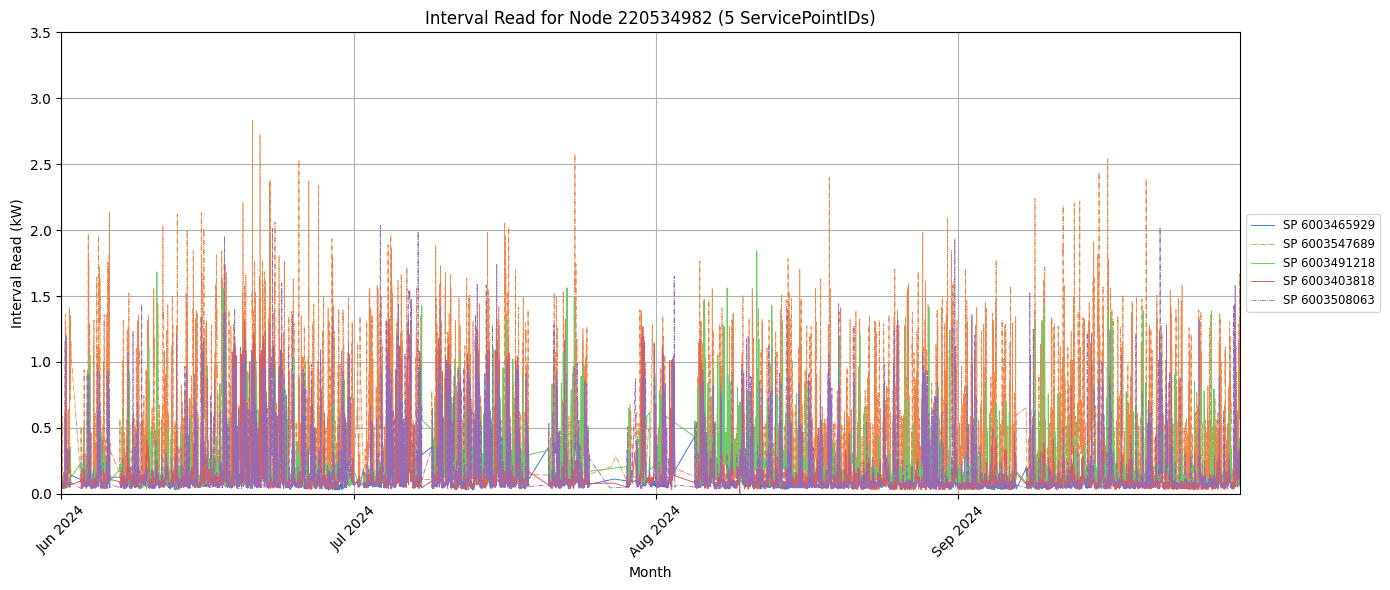

In [14]:
# LOAD ID 1
# SUMMER 
# INDIVIDUAL

plt.figure(figsize=(14, 6))
df_2024_summer = df_2024_summer.copy()
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)


# Define colors and styles for each line
linestyles = ['-', '-.', '-']
linewidths = [0.7, 0.6, 0.7]

colors = sns.color_palette("muted", n_colors=len(service_ids))  # or "colorblind", "muted", "deep"

non_coinc_peak_sum = 0
non_coinc_peaks_by_id = {}

for i, sp_id in enumerate(service_ids):
    sp_data = df_2024_summer[df_2024_summer['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        # Get individual peak
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        peak_value = non_coinc_peak['INTERVAL_READ']
        non_coinc_peaks_by_id[sp_id] = peak_value
        non_coinc_peak_sum += peak_value

        # Plot line only (no peak markers)
        plt.plot(
            sp_data['ENDTIME_EST'], 
            sp_data['INTERVAL_READ'], 
            color=colors[i],
            linestyle=linestyles[i % 3],
            linewidth=linewidths[i % 3],
            label=f'SP {sp_id}'
        )

# ---- Print individual peaks ----
print("Individual Non-Coincident Peaks:")
for sp_id, peak_val in non_coinc_peaks_by_id.items():
    print(f"  - SP {sp_id}: {peak_val:.3f} kW")

# ---- Print total ----
print(f"\nTotal Non-Coincident Peak Load: {non_coinc_peak_sum:.3f} kW ")

# Format x-axis as months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-09-30'))
plt.ylim(0, 3.5)

# Labels, legend, and formatting
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Interval Read for Node {load_id["res"]} ({len(service_ids)} ServicePointIDs)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Summer Coincident peak for entire feeder: 356.447 kW. Time: 2024-07-15 17:00:00
Non Coincident SUMMER Peak Load: 1319.0810000000001 kW
Coincident peak: 5.077 kW. Time: 2024-06-17 17:45:00
service point ID #['6003465929', '6003547689', '6003491218', '6003403818', '6003508063']


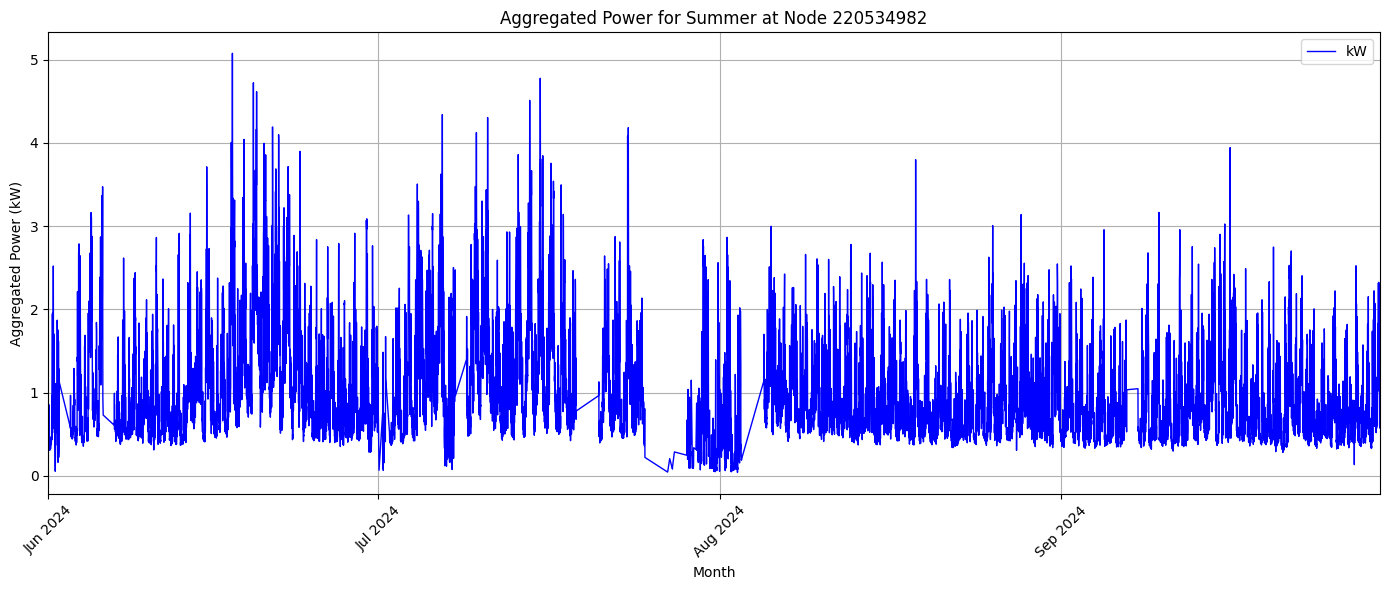

In [23]:
# LOAD ID 1
# SUMMER 

# Make sure SERVICEPOINTID is string
df_2024_summer = df_2024_summer.copy()

## CALCULATE AGGREGATE PEAK FOR ENTIRE FEEDER FOR SUMMER
agg_df_feeder = df_2024_summer.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()
coinc_peak_row_feeder = agg_df_feeder.loc[agg_df_feeder['INTERVAL_READ'].idxmax()]
coinc_peak_value_feeder = coinc_peak_row_feeder['INTERVAL_READ']
coinc_peak_time_feeder = coinc_peak_row_feeder['ENDTIME_EST']

print(f"Summer Coincident peak for entire feeder: {coinc_peak_value_feeder} kW. Time: {coinc_peak_time_feeder}")

# CALCULATE NON COINCIDENT SUMMER PEAK FOR ENTIRE FEEDER

non_coincident_peaks = df_2024_summer.groupby('SERVICEPOINTID')['INTERVAL_READ'].max()                        
non_coincident_peak_load = non_coincident_peaks.sum()

print(f"Non Coincident SUMMER Peak Load: {non_coincident_peak_load} kW")
#### CALCULATE PEAK SUMMER LOAD FOR FEEDER NODE 
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024_summer[df_2024_summer['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kW)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

#################################
# CHECKS: 

# print(f"Original total: {filtered_df['INTERVAL_READ'].sum()}")
# print(f"Aggregated total: {agg_df['INTERVAL_READ'].sum()}")

# # Pick a timestamp from the aggregated result
# test_timestamp = agg_df['ENDTIME_EST'].iloc[0]

# # Manually sum INTERVAL_READ values for that timestamp in the filtered_df
# manual_sum = filtered_df[filtered_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].sum()

# # Compare it to the aggregated value
# agg_sum = agg_df[agg_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].values[0]

# print(f"Manual sum: {manual_sum}, Aggregated sum: {agg_sum}")
#################################

## CALCULATE PEAK SUMMER LOAD

# Coincident aggregated peak

# Find the row with the maximum load
coinc_peak_row = agg_df.loc[agg_df['INTERVAL_READ'].idxmax()]

print(f"Coincident peak: {coinc_peak_row['INTERVAL_READ']} kW. Time: {coinc_peak_row['ENDTIME_EST']}")


print(f"service point ID #{service_ids}")
# Plot kW
plt.figure(figsize=(14, 6))
plt.plot(agg_df['ENDTIME_EST'], agg_df['INTERVAL_READ'], label='kW', color='blue', linewidth=1)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06-01'), pd.to_datetime('2024-09-30'))

# Labels
plt.xlabel('Month')
plt.ylabel('Aggregated Power (kW)')
plt.title(f'Aggregated Power for Summer at Node {load_id["res"]}')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Coincident peak: 5.077 kW. Time: 2024-06-17 17:45:00


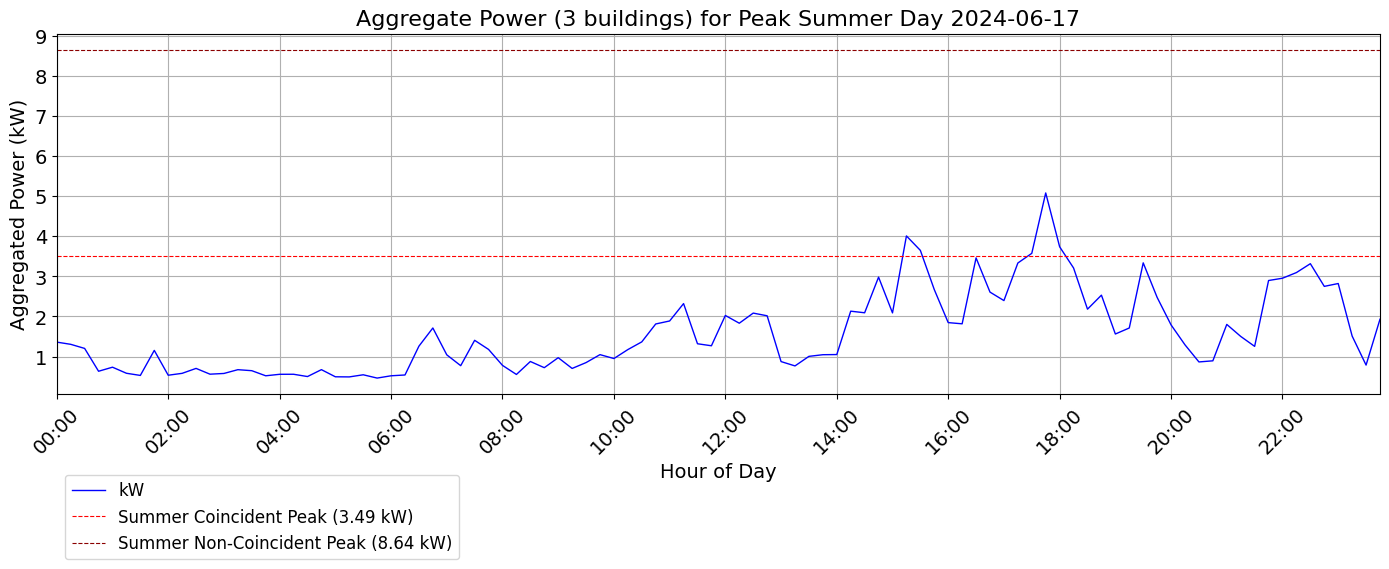

In [16]:
## SUMMER SINGLE DAY PEAK
## AGGREGATE LOAD

# Make sure SERVICEPOINTID is string
df_2024_summer = df_2024_summer.copy()
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024_summer[df_2024_summer['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kW)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()


## CALCULATE PEAK SUMMER LOAD

# Coincident aggregated peak

# Find the row with the maximum load
coinc_peak_row = agg_df.loc[agg_df['INTERVAL_READ'].idxmax()]

print(f"Coincident peak: {coinc_peak_row['INTERVAL_READ']} kW. Time: {coinc_peak_row['ENDTIME_EST']}")

coinc_peak_time = coinc_peak_row['ENDTIME_EST']
coinc_peak_value = coinc_peak_row['INTERVAL_READ']

peak_day = coinc_peak_time.date()

peak_day_data = agg_df[agg_df['ENDTIME_EST'].dt.date == peak_day]

# Plot the 24-hour load profile of the peak day
plt.figure(figsize=(14, 6))
plt.plot(peak_day_data['ENDTIME_EST'], peak_day_data['INTERVAL_READ'], label='kW', color='blue', linewidth=1)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(peak_day_data['ENDTIME_EST'].min(), peak_day_data['ENDTIME_EST'].max())

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
# Add non coincident peak lines (horizontal)
plt.axhline(y=8.64, color='darkred', linestyle='--', linewidth=0.8, label='Summer Non-Coincident Peak (8.64 kW)')
            
# Labels
plt.xlabel('Hour of Day',fontsize=14 )
plt.ylabel('Aggregated Power (kW)',fontsize=14)
plt.title(f'Aggregate Power (3 buildings) for Peak Summer Day {peak_day}', fontsize=16)
plt.grid(True)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, -0.20),  # Bottom left outside the plot
    fontsize='large',
    frameon=True,
    ncol=1
)
plt.xticks(rotation=45, fontsize='14')
plt.yticks(fontsize='14')
plt.tight_layout()

plt.savefig('Aggregate Power for summer single day.png', dpi=300, bbox_inches='tight')
plt.show()


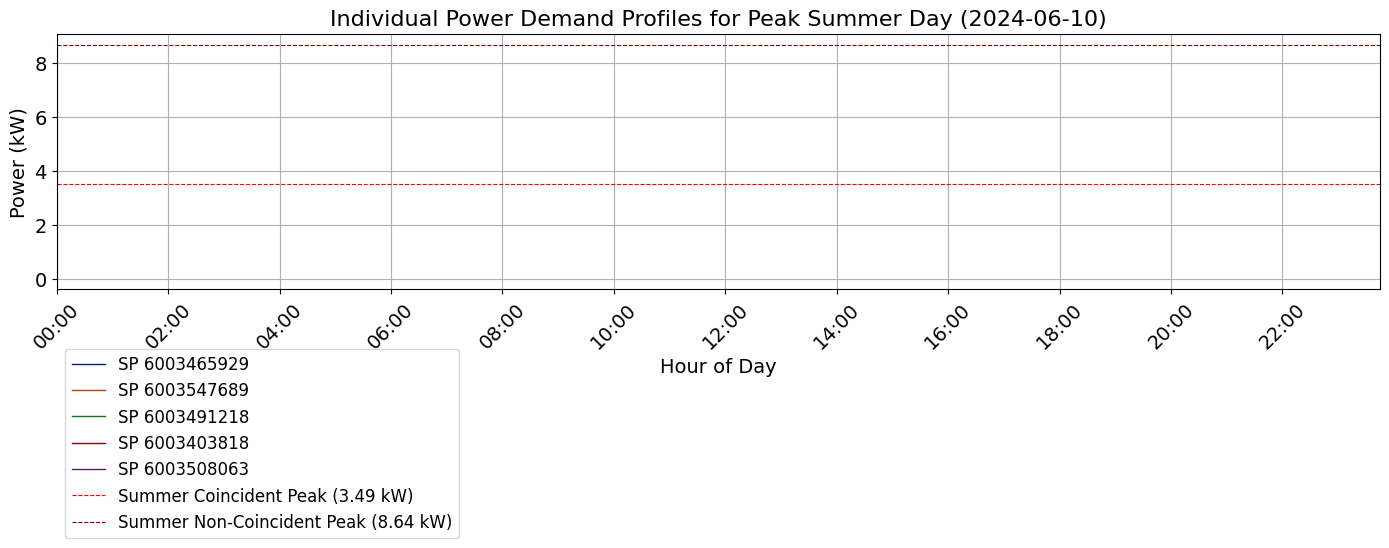

In [17]:
# LOAD ID 1
# SUMMER DAY PEAK
# INDIVIDUAL


from datetime import datetime

plt.figure(figsize=(14, 6))

# Ensure SERVICEPOINTID is string
df_2024_summer = df_2024_summer.copy()
df_2024_summer['SERVICEPOINTID'] = df_2024_summer['SERVICEPOINTID'].astype(str)

# Define styles
linestyles = ['-', '-', '-']
linewidths = [1, 1, 1]
colors = sns.color_palette("dark", n_colors=len(service_ids))


# Set coincident peak day
coinc_peak_day = pd.to_datetime("2024-06-10").date()

for i, sp_id in enumerate(service_ids):
    sp_data = df_2024_summer[df_2024_summer['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:

        # Filter data for coincident peak day
        coinc_peak_data = sp_data[sp_data['ENDTIME_EST'].dt.date == coinc_peak_day]

        # Plot line only
        plt.plot(
            coinc_peak_data['ENDTIME_EST'],
            coinc_peak_data['INTERVAL_READ'],
            color=colors[i],
            linestyle=linestyles[i % len(linestyles)],
            linewidth=linewidths[i % len(linewidths)],
            label=f'SP {sp_id}'
        )

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(peak_day_data['ENDTIME_EST'].min(), peak_day_data['ENDTIME_EST'].max())

# Add coincident peak lines (horizontal)
plt.axhline(y=3.494, color='red', linestyle='--', linewidth=0.8, label='Summer Coincident Peak (3.49 kW)')
# Add non coincident peak lines (horizontal)
plt.axhline(y=8.64, color='darkred', linestyle='--', linewidth=0.8, label='Summer Non-Coincident Peak (8.64 kW)')


# Labels and formatting with larger fonts
plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Power (kW)", fontsize=14)
plt.title("Individual Power Demand Profiles for Peak Summer Day (2024-06-10)", fontsize=16)
plt.grid(True)

# Legend at bottom left
plt.legend(
    loc='upper left',
    bbox_to_anchor=(0, -0.20),
    fontsize='large',
    frameon=True,
    ncol=1
)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig('Load Profiles on Coincident Summer Peak Day (2024-06-10).png', dpi=300, bbox_inches='tight')

plt.show()


In [26]:
# # LOAD ID 1
# # WINTER 
## INDIVIDUAL LOADS
df_2024_winter = df_2024_winter.copy()
non_coinc_peak_sum = 0
non_coinc_peaks_by_id = {}

for i, sp_id in enumerate(service_ids):
    print(f"service id = #{service_ids}")
    sp_data = df_2024_winter[df_2024_winter['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        peak_value = non_coinc_peak['INTERVAL_READ']
        non_coinc_peaks_by_id[sp_id] = peak_value
        non_coinc_peak_sum += peak_value

# ---- Print individual peaks ----
print("Winter Non-Coincident Peaks:")
for sp_id, peak_val in non_coinc_peaks_by_id.items():
    print(f"  - SP {sp_id}: {peak_val:.3f} kW")

# ---- Print total ----
print(f"\nTotal Winter Non-Coincident Peak Load: {non_coinc_peak_sum:.3f} kW")


# Split winter data into two seasonal subsets
df_jan_jun = df_2024_winter[(df_2024_winter['ENDTIME_EST'] >= '2024-01-01') & 
                            (df_2024_winter['ENDTIME_EST'] < '2024-07-01')]

df_oct_dec = df_2024_winter[(df_2024_winter['ENDTIME_EST'] >= '2024-10-01') & 
                            (df_2024_winter['ENDTIME_EST'] < '2025-01-01')]

# Define colors and styles
linestyles = ['-', '-.', '--']
linewidths = [0.7, 0.6, 0.4]
#alpha=0.5 if i == 2 else 1.0
alphas = [1.0, 0.6, 0.6]
colors = sns.color_palette("muted", n_colors=len(service_ids))

# ---------- Jan–Jun Plot ----------
plt.figure(figsize=(14, 6))

for i, sp_id in enumerate(service_ids):
    sp_data = df_jan_jun[df_jan_jun['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        non_coinc_peak_sum_jan_jun += non_coinc_peak['INTERVAL_READ']

        plt.plot(
            sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'],
            color=colors[i],
            linestyle=linestyles[i % 3],
            linewidth=linewidths[i % 3],
            alpha = alphas[i%3],
            label=f'SP {sp_id}'
        )

plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2024-06-01'))
plt.ylim(0, 5.0)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Winter Load (Jan–Jun) for Node {load_id["res"]} ({len(service_ids)} ServicePointIDs)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#### Oct–Dec Plot ----------
plt.figure(figsize=(14, 6))

for i, sp_id in enumerate(service_ids):
    sp_data = df_oct_dec[df_oct_dec['SERVICEPOINTID'] == sp_id]

    if not sp_data.empty:
        non_coinc_peak = sp_data.loc[sp_data['INTERVAL_READ'].idxmax()]
        non_coinc_peak_sum_oct_dec += non_coinc_peak['INTERVAL_READ']

        plt.plot(
            sp_data['ENDTIME_EST'], sp_data['INTERVAL_READ'],
            color=colors[i],
            linestyle=linestyles[i % 3],
            linewidth=linewidths[i % 3],
            label=f'SP {sp_id}'
        )
# plt.xlim(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-01-01'))
# plt.ylim(0, 5.0)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.title(f'Winter Load (Oct–Dec) for Node {load_id["res"]} ({len(service_ids)} ServicePointIDs)')
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



service id = #['6003465929', '6003547689', '6003491218', '6003403818', '6003508063']
service id = #['6003465929', '6003547689', '6003491218', '6003403818', '6003508063']
service id = #['6003465929', '6003547689', '6003491218', '6003403818', '6003508063']
service id = #['6003465929', '6003547689', '6003491218', '6003403818', '6003508063']
service id = #['6003465929', '6003547689', '6003491218', '6003403818', '6003508063']
Winter Non-Coincident Peaks:
  - SP 6003465929: 0.777 kW
  - SP 6003547689: 2.552 kW
  - SP 6003491218: 2.110 kW
  - SP 6003403818: 0.690 kW
  - SP 6003508063: 1.901 kW

Total Winter Non-Coincident Peak Load: 8.030 kW


NameError: name 'non_coinc_peak_sum_jan_jun' is not defined

<Figure size 1400x600 with 0 Axes>

Winter Coincident peak for entire feeder: 369.599 kW. Time: 2024-11-03 01:30:00
Non Coincident WINTER Peak Load: 1292.6879999999999 kW
Coincident peak: 4.45 kW. Time: 2024-11-17 10:15:00


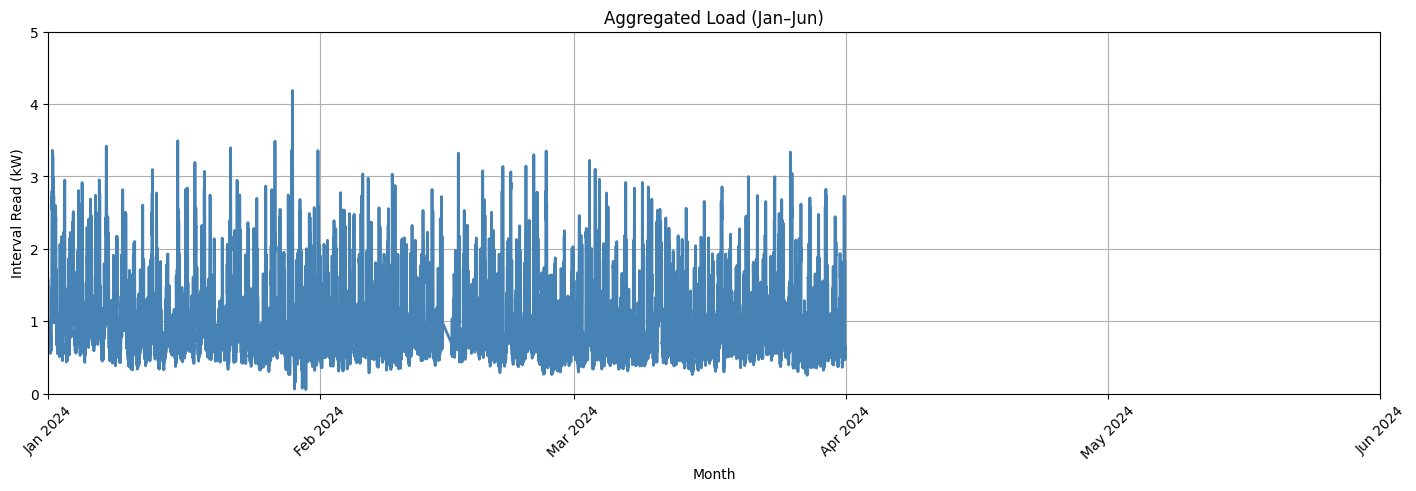

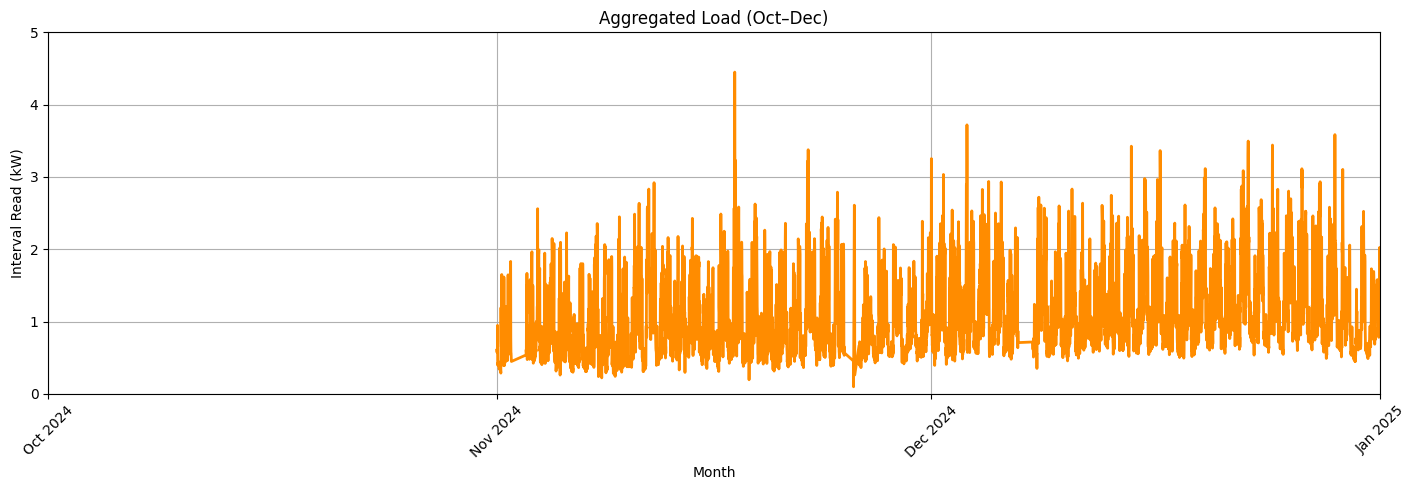

In [22]:
# LOAD ID 1
# WINTER
## AGGREGATED

df_2024_winter = df_2024_winter.copy()

## CALCULATE AGGREGATE WINTER PEAK FOR ENTIRE FEEDER
agg_df_feeder = df_2024_winter.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()
coinc_peak_row_feeder = agg_df_feeder.loc[agg_df_feeder['INTERVAL_READ'].idxmax()]
coinc_peak_value_feeder = coinc_peak_row_feeder['INTERVAL_READ']
coinc_peak_time_feeder = coinc_peak_row_feeder['ENDTIME_EST']

print(f"Winter Coincident peak for entire feeder: {coinc_peak_value_feeder} kW. Time: {coinc_peak_time_feeder}")
## CALCULATE AGGREGATE WINTER NON COINCIDENT PEAK FOR ENTIRE FEEDER
non_coincident_peaks = df_2024_winter.groupby('SERVICEPOINTID')['INTERVAL_READ'].max()                        
non_coincident_peak_load = non_coincident_peaks.sum()

print(f"Non Coincident WINTER Peak Load: {non_coincident_peak_load} kW")

### PEAK WINTER LOAD FOR FEEDER NODE
# Make sure SERVICEPOINTID is string

df_2024_winter['SERVICEPOINTID'] = df_2024_winter['SERVICEPOINTID'].astype(str)

# Filter for selected service points
filtered_df = df_2024_winter[df_2024_winter['SERVICEPOINTID'].isin(service_ids)]

# Group by timestamp and sum load (in kW)
agg_df = filtered_df.groupby('ENDTIME_EST')['INTERVAL_READ'].sum().reset_index()

## CALCULATE PEAK WINTER LOAD
# Coincident aggregated peak

# Find the row with the maximum load
coinc_peak_row = agg_df.loc[agg_df['INTERVAL_READ'].idxmax()]

print(f"Coincident peak: {coinc_peak_row['INTERVAL_READ']} kW. Time: {coinc_peak_row['ENDTIME_EST']}")

# #################################
# # CHECKS: 

# print(f"Original total: {filtered_df['INTERVAL_READ'].sum()}")
# print(f"Aggregated total: {agg_df['INTERVAL_READ'].sum()}")

# # Pick a timestamp from the aggregated result
# test_timestamp = agg_df['ENDTIME_EST'].iloc[0]

# # Manually sum INTERVAL_READ values for that timestamp in the filtered_df
# manual_sum = filtered_df[filtered_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].sum()

# # Compare it to the aggregated value
# agg_sum = agg_df[agg_df['ENDTIME_EST'] == test_timestamp]['INTERVAL_READ'].values[0]

# print(f"Manual sum: {manual_sum}, Aggregated sum: {agg_sum}")
# #################################



# Plot kW

# Split aggregated data
agg_jan_jun = agg_df[(agg_df['ENDTIME_EST'] >= '2024-01-01') & (agg_df['ENDTIME_EST'] < '2024-07-01')]
agg_oct_dec = agg_df[(agg_df['ENDTIME_EST'] >= '2024-10-01') & (agg_df['ENDTIME_EST'] < '2025-01-01')]

# ---- Plot Jan–Jun ----
plt.figure(figsize=(14, 5))
plt.plot(agg_jan_jun['ENDTIME_EST'], agg_jan_jun['INTERVAL_READ'], color='steelblue', linewidth=2)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title('Aggregated Load (Jan–Jun)')
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(pd.to_datetime('2024-01-01'), pd.to_datetime('2024-06-01'))
plt.ylim(0, 5.0)
plt.show()

# ---- Plot Oct–Dec ----
plt.figure(figsize=(14, 5))
plt.plot(agg_oct_dec['ENDTIME_EST'], agg_oct_dec['INTERVAL_READ'], color='darkorange', linewidth=2)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title('Aggregated Load (Oct–Dec)')
plt.xlabel('Month')
plt.ylabel('Interval Read (kW)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-01-01'))
plt.ylim(0, 5.0)
plt.show()
